In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ball_by_ball_ipl.csv')
print("Rows and Columns : ", df.shape)

# Data Cleaning 
# standardising stadium names
venue_map = {
     "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
     "Sardar Patel Stadium": "Narendra Modi Stadium",
     "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium",
     "Feroz Shah Kotla": "Arun Jaitley Stadium",
     "Zayed Cricket Stadium": "Sheikh Zayed Stadium",
     "De Beers Diamond Oval": "Kimberley Oval",
     "Rajiv Gandhi International Stadium": "Uppal Stadium",
     "Dr Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "ACA-VDCA Stadium",
     "Shaheed Veer Narayan Singh International Stadium": "Raipur International Cricket Stadium",
     "JSCA International Stadium Complex": "Ranchi Stadium",
     "Barsapara Cricket Stadium": "Assam Cricket Association Stadium"
}
df['Venue'] = df['Venue'].replace(venue_map)

#standardising team names
team_map = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Gujarat Lions": "Gujarat Titans",
    "Rising Pune Supergiant": "Pune Warriors",
    "Rising Pune Supergiants": "Pune Warriors"
}
df['Bat First'] = df['Bat First'].replace(team_map)
df['Bat Second'] = df['Bat Second'].replace(team_map)
df['Winner'] = df['Winner'].replace(team_map)

# standardising player names
df['Batter'] = df['Batter'].str.strip().str.title()    
df['Bowler'] = df['Bowler'].str.strip().str.title()
df['Non Striker'] = df['Non Striker'].str.strip().str.title()
df['Player Out'] = df['Player Out'].str.strip().str.title() 
df['Batter'].nunique()   # df['Batter'] is of series type, so we need to convert every value to string

Rows and Columns :  (239693, 35)


637

In [2]:
df = df[df['Innings']==1]
model_df = df[['Match ID','Venue','Bat First','Bat Second','Over','Innings Runs','Innings Wickets']]

model_df = model_df.rename(columns={
    'Innings Runs': 'current_score',
    'Innings Wickets': 'wickets_lost',
    'Over': 'overs_completed',
    'Venue': 'venue',
    'Bat First': 'batting_team',
    'Bat Second': 'bowling_team'
})

model_df['recent_overs_score'] = model_df.groupby('Match ID')['current_score'].diff(periods=30)
model_df['final_score'] = model_df.groupby('Match ID')['current_score'].transform('max')
model_df = model_df[model_df['overs_completed'] > 5.0]
model_df['recent_overs_score'] = model_df['recent_overs_score'].fillna(0)
print(model_df.dtypes)
print(model_df.head())

Match ID                int64
venue                  object
batting_team           object
bowling_team           object
overs_completed         int64
current_score           int64
wickets_lost            int64
recent_overs_score    float64
final_score             int64
dtype: object
    Match ID         venue         batting_team           bowling_team  \
30   1359507  Eden Gardens  Chennai Super Kings  Kolkata Knight Riders   
31   1359507  Eden Gardens  Chennai Super Kings  Kolkata Knight Riders   
32   1359507  Eden Gardens  Chennai Super Kings  Kolkata Knight Riders   
33   1359507  Eden Gardens  Chennai Super Kings  Kolkata Knight Riders   
34   1359507  Eden Gardens  Chennai Super Kings  Kolkata Knight Riders   

    overs_completed  current_score  wickets_lost  recent_overs_score  \
30                6             46             0                42.0   
31                6             50             0                46.0   
32                6             51             0       

In [3]:
X = model_df.drop(columns=['Match ID', 'final_score'])
y = model_df['final_score']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = ['venue', 'batting_team', 'bowling_team']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], 
    remainder='passthrough'
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train) 
y_pred = rf_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred) 
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Model Training Complete!")
print("============ MODEL ACCURACY REPORT ============")
print(f"Mean Absolute Error (MAE): {mae:.2f} runs")
print(f"Root Mean Squared Error (RMSE)  : {rmse:.2f} runs")
print(f"Mean Absolute % Error (MAPE)   : {mape * 100:.2f}%")
print(f"R-squared (R²) Score           : {r2:.4f}")
print("===============================================")

Model Training Complete!
============ MODEL ACCURACY REPORT ============
Mean Absolute Error (MAE): 10.49 runs
Root Mean Squared Error (RMSE)  : 14.21 runs
Mean Absolute % Error (MAPE)   : 6.62%
R-squared (R²) Score           : 0.7759


In [5]:
def predict_score(model, venue, batting_team, bowling_team, current_score, wickets_lost, overs_completed, runs_last_5):
    input_data = pd.DataFrame([[venue, batting_team, bowling_team, current_score, wickets_lost, overs_completed, runs_last_5]], 
                              columns=['venue', 'batting_team', 'bowling_team', 'current_score', 'wickets_lost', 'overs_completed', 'recent_overs_score'])
    prediction = model.predict(input_data)
    return int(prediction[0])

predicted_total = predict_score(rf_pipeline, 'Eden Gardens', 'Kolkata Knight Riders', 'Mumbai Indians', 110, 3, 12.0, 45)
print(f"Predicted Final Score: {predicted_total}")

Predicted Final Score: 189


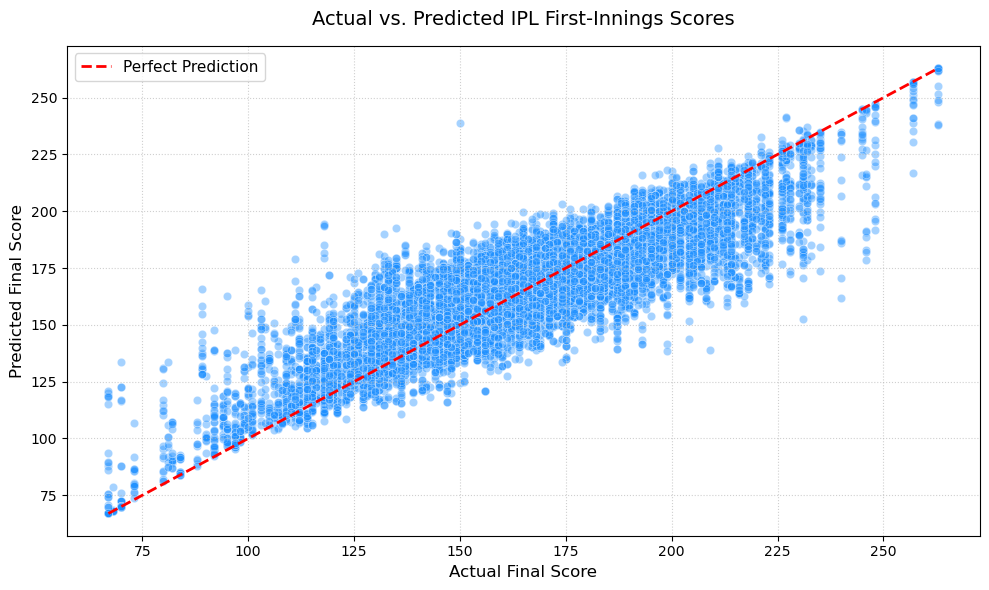

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='dodgerblue', edgecolor='w')

max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted IPL First-Innings Scores', fontsize=14, pad=15)
plt.xlabel('Actual Final Score', fontsize=12)
plt.ylabel('Predicted Final Score', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

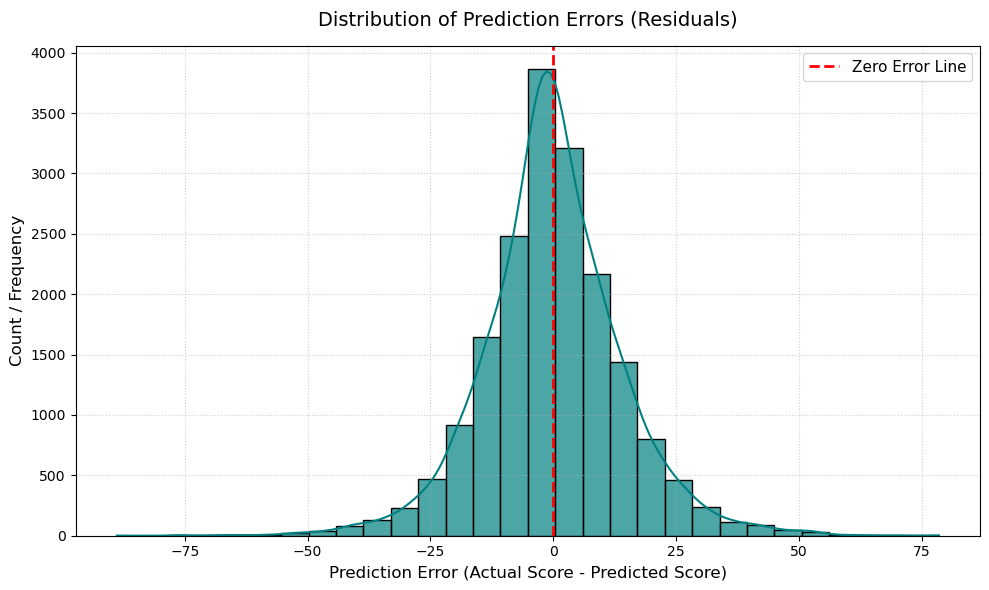

In [7]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='teal', bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=14, pad=15)
plt.xlabel('Prediction Error (Actual Score - Predicted Score)', fontsize=12)
plt.ylabel('Count / Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

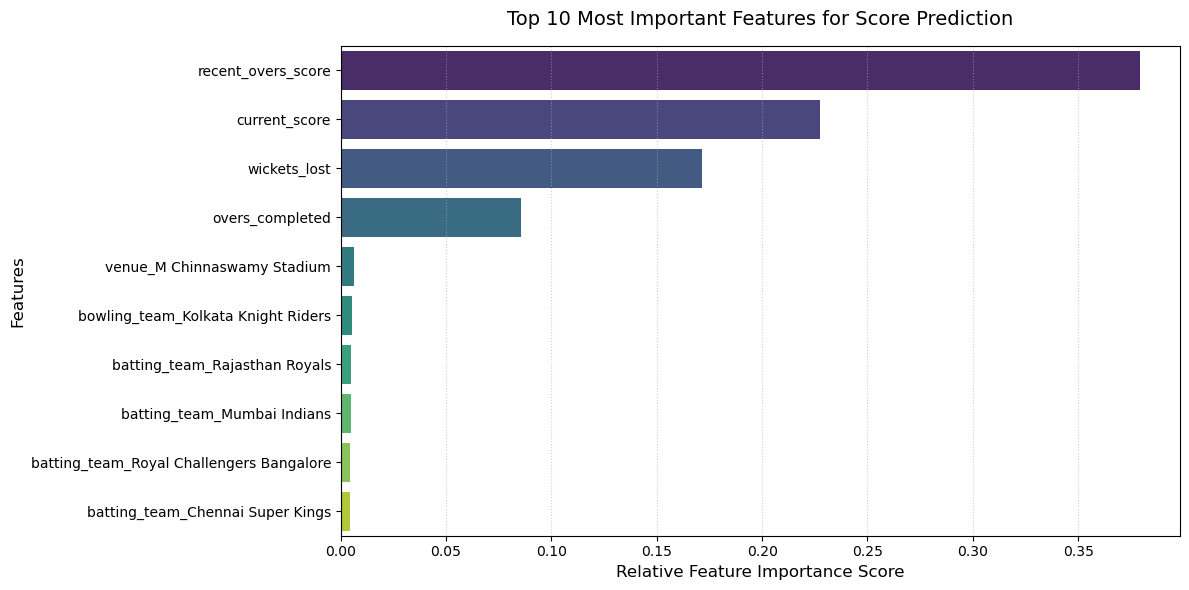

In [8]:
try:
    cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
    encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))    
    numeric_features = [col for col in X_train.columns if col not in categorical_features]
    all_feature_names = encoded_cat_features + numeric_features
    importances = rf_pipeline.named_steps['regressor'].feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10) 
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
    plt.title('Top 10 Most Important Features for Score Prediction', fontsize=14, pad=15)
    plt.xlabel('Relative Feature Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not plot feature importance due to error: {e}")

In [9]:
import pickle

with open('ipl_score_model.pkl', 'wb') as f:
    pickle.dump(rf_pipeline, f)

print("Professional Pipeline saved as ipl_score_model.pkl")

Professional Pipeline saved as ipl_score_model.pkl
